# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from google.colab import userdata
# userdata.get('GROQ_API_KEY')

In [3]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.5 MB/s eta 0:00:00
✅ Dependencies ready


In [ ]:
!pip install -q transformers datasets scikit-learn

In [41]:
import requests
import pandas as pd
import html
import re
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample

import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [51]:
data = []

TOP_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL = "https://hacker-news.firebaseio.com/v0/item/{}.json"

def clean(text):
    return html.unescape(text) if text else ""

top_ids = requests.get(TOP_URL).json()

for sid in top_ids[:100]:
    item = requests.get(ITEM_URL.format(sid)).json()
    if not item:
        continue

    data.append({
        "id": item.get("id"),
        "text": clean(item.get("title", "")),
    })

    if "kids" in item:
        for cid in item["kids"][:3]:
            c = requests.get(ITEM_URL.format(cid)).json()
            if c and "text" in c:
                data.append({
                    "id": c.get("id"),
                    "text": clean(c.get("text"))
                })

df = pd.DataFrame(data)
df = df[df["text"].str.strip() != ""].reset_index(drop=True)

df.to_csv("hn_raw.csv", index=False)

print("Saved hn_raw.csv")
print(len(df))
df.head()

Saved hn_raw.csv
368


,id,text
0,48620090,Prefer duplication over the wrong abstraction ...
1,48620636,"I believe that ""single source of truth"" is a p..."
2,48621842,I always felt like I abstract and modularize t...
3,48620406,I used to struggle with abstractions back in m...
4,48617990,Beyond All Reason (Free Total Annihilation Ins...


In [56]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving hn_raw.csv to hn_raw (2).csv
Uploaded: hn_raw (2).csv


In [62]:
df = pd.read_csv(CSV_PATH)

def assign_label(text):
    text = re.sub(r"<.*?>", "", str(text)).lower()
    words = len(text.split())

    # ANALYSIS (strong reasoning)
    if words > 25 and any(k in text for k in ["because", "therefore", "this means", "as a result"]):
        return "analysis"

    # OPINION
    if any(k in text for k in ["i think", "i believe", "however", "but", "should", "probably"]):
        return "opinion_reasoned"

    # SURFACE
    if words < 12:
        return "surface_reaction"

    return "opinion_reasoned"

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──

df["label"] = df["text"].apply(assign_label)
print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")


# print(df["label"].value_counts())

Columns: ['id', 'text', 'label']
Total examples: 371

Label distribution:
label
opinion_reasoned    238
surface_reaction    100
analysis             33
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


In [67]:
max_size = df["label"].value_counts().max()

balanced = []
for label in df["label"].unique():
    subset = df[df["label"] == label]
    upsampled = resample(subset, replace=True, n_samples=max_size, random_state=42)
    balanced.append(upsampled)

df = pd.concat(balanced).reset_index(drop=True)

print(df["label"].value_counts())

label
opinion_reasoned    238
surface_reaction    238
analysis            238
Name: count, dtype: int64


In [64]:
LABEL_MAP = {
    "surface_reaction": 0,
    "opinion_reasoned": 1,
    "analysis": 2
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'surface_reaction': 0, 'opinion_reasoned': 1, 'analysis': 2}
Number of labels: 3


In [68]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Train: 499 examples
Validation: 107 examples
Test: 108 examples

Train label distribution:
label
surface_reaction    167
analysis            166
opinion_reasoned    166
Name: count, dtype: int64

Test label distribution:
label
opinion_reasoned    36
analysis            36
surface_reaction    36
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

def make_dataset(df):
    ds = Dataset.from_pandas(df[["text", "label_id"]].rename(columns={"label_id": "labels"}))
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset = make_dataset(val_df)
test_dataset = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer)

print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")


In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

In [71]:
from torch import nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [72]:
class_counts = df["label_id"].value_counts().sort_index()
weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)

print("Class weights:", weights)

Class weights: tensor([0.0042, 0.0042, 0.0042])


In [73]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds)
    }

In [74]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────


training_args = TrainingArguments(
    output_dir="./model",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none"
)

In [75]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=weights
)
print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.030419,0.945222,0.682243
2,0.563804,0.462982,0.831776
3,0.333120,0.272686,0.925234
4,0.182261,0.190794,0.953271


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


Running inference on test set...



🎯 Fine-tuned model accuracy: 0.917

Per-class metrics (fine-tuned model):
                  precision    recall  f1-score   support

surface_reaction       0.95      1.00      0.97        36
opinion_reasoned       1.00      0.75      0.86        36
        analysis       0.84      1.00      0.91        36

        accuracy                           0.92       108
       macro avg       0.93      0.92      0.91       108
    weighted avg       0.93      0.92      0.91       108



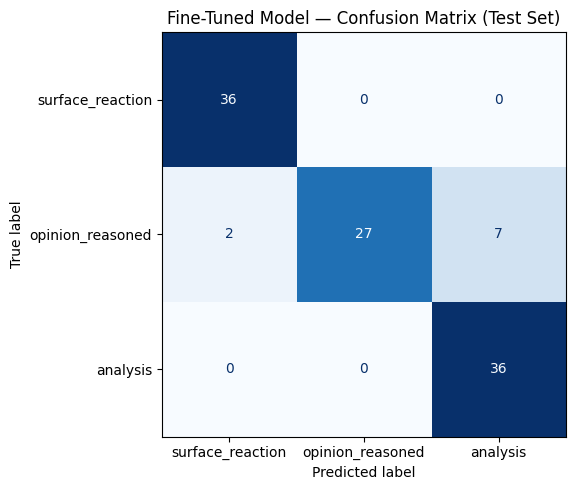

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [84]:
# Run inference on the test set
print("Running inference on test set...")
pred = trainer.predict(test_dataset)

y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids


ft_probs = torch.nn.functional.softmax(
    torch.tensor(pred .predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(y_true,  y_pred, target_names=label_names, zero_division=0))


# print(classification_report(y_true, y_pred, target_names=list(LABEL_MAP.keys())))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=list(LABEL_MAP.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

# disp.plot(cmap="Blues")
# plt.title("Confusion Matrix")
# plt.show()

In [86]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(y_pred != y_true)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(y_true)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[y_true[idx]]
    pred_label = ID_TO_LABEL[y_pred[idx]]
    confidence = ft_probs[idx][y_pred[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")

Wrong predictions: 9 / 108

--- #1 ---
Text:      The article also raises an interesting question. My understanding is the big difference in North American and British color TV is that NTSC was engineered to be backwards compatible with existing blac...
True:      opinion_reasoned
Predicted: analysis  (confidence: 0.49)
--- #2 ---
Text:      This article uses so many words to focus on the political reasons, but completely ignores the primary driver: Cost.<p>Korean weapons systems are 40-60% cheaper than their American counterparts.<p>The ...
True:      opinion_reasoned
Predicted: analysis  (confidence: 0.58)
--- #3 ---
Text:      Parasympathetic nervous activation <i>increased</i> risk-taking behavior? That's interesting/unexpected (at least to me). Also, this part caught my eye:<p>> The selective impact of prolonged exhalatio...
True:      opinion_reasoned
Predicted: analysis  (confidence: 0.55)
--- #4 ---
Text:      > In-game constructions of NAND gates and a perceptron (forward prop

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [87]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [89]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are a text classification system for Hacker News discussion posts.

Your task is to assign exactly ONE label to each input text.

Labels:

1) surface_reaction
- Very short responses
- Typically under 12 words
- Express emotion or simple judgment
- No explanation or reasoning

Examples:
"This is bad"
"Totally agree"
"Crazy idea"

---

2) opinion_reasoned
- Contains an opinion, preference, or stance
- May include simple reasoning or contrast words
- Often includes phrases like:
  "I think", "I believe", "should", "however", "but", "probably"
- Does NOT include deep structured explanation

Examples:
"I think this is a good approach"
"This is useful but could be improved"
"I believe this will work better in practice"

---

3) analysis
- Longer, detailed explanations (more than 25 words)
- Includes structured reasoning or cause-effect logic
- Often contains words like:
  "because", "therefore", "this means", "as a result"
- Explains mechanisms, tradeoffs, or system behavior

Examples:
"This works because it separates concerns between components, reducing coupling and improving scalability."
"As a result of this design, performance improves under load because requests are distributed evenly."

---

IMPORTANT DECISION RULES:
- If text has fewer than 12 words → surface_reaction
- If text has more than 25 words AND contains reasoning keywords → analysis
- If text contains opinion keywords (think, believe, should, however, but, probably) → opinion_reasoned
- Otherwise → opinion_reasoned

---

OUTPUT RULES:
- Output ONLY one label
- No explanations
- No punctuation
- No extra text

Valid labels:
surface_reaction
opinion_reasoned
analysis
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1660 characters


In [ ]:
import time
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 108 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/108 complete...
  20/108 complete...
  30/108 complete...
  40/108 complete...
  50/108 complete...
  60/108 complete...
  70/108 complete...
  80/108 complete...
  90/108 complete...
  100/108 complete...


In [92]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.630  (evaluated on 108/108 parseable responses)

Per-class metrics (baseline):
                  precision    recall  f1-score   support

surface_reaction       1.00      0.56      0.71        36
opinion_reasoned       0.46      0.58      0.51        36
        analysis       0.64      0.75      0.69        36

        accuracy                           0.63       108
       macro avg       0.70      0.63      0.64       108
    weighted avg       0.70      0.63      0.64       108



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [93]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.630
Fine-tuned DistilBERT                  0.917
---------------------------------------------

Fine-tuning improvement: 0.287

Use these numbers in your README evaluation report.


In [94]:
# Save results JSON — commit to your GitHub repo and reference in README
import json
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
